In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

In [2]:
notebook = "syn1_Friedman_20_500_long"

In [3]:
import numpy as np
import pandas as pd

# Friedman (1991): 10 predictors, only the first 5 are relevant
rng = np.random.default_rng(42)
n_samples = 2000
noise_std = 1.0

# X_j ~ Uniform(0, 1), j = 1, ..., 10
X_np = rng.uniform(0.0, 1.0, size=(n_samples, 10))
X = pd.DataFrame(X_np, columns=[f"x{i}" for i in range(1, 11)])

# y = 10 sin(pi x1 x2) + 20 (x3 - 0.5)^2 + 10 x4 + 5 x5 + eps
eps = rng.normal(0.0, noise_std, size=n_samples)
y = (
    10.0 * np.sin(np.pi * X["x1"] * X["x2"])
    + 20.0 * (X["x3"] - 0.5) ** 2
    + 10.0 * X["x4"]
    + 5.0 * X["x5"]
    + eps
)

In [4]:
X = X.values.astype(float)
y = np.array(y).reshape(-1)

In [5]:
ndpost = 500
nskip = 5000
n_trees = 100

In [6]:
from experiment import run_parallel_experiments

# Run parallel chains with temperature schedule
results = run_parallel_experiments(
    X, y, ndpost, nskip, n_trees, notebook,
    tree_alpha=0.95, tree_beta=2.0, m_tries=10,
    n_chains=20, n_jobs=5, store_preds=True,
    n_test_points=100,  # Store all test points if not specified
    start_temp=1.0, end_temp=1.0
)

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   3 tasks      | elapsed:  9.3min
[Parallel(n_jobs=5)]: Done   8 tasks      | elapsed: 18.8min
[Parallel(n_jobs=5)]: Done  14 out of  20 | elapsed: 28.1min remaining: 12.1min
[Parallel(n_jobs=5)]: Done  17 out of  20 | elapsed: 37.0min remaining:  6.5min
[Parallel(n_jobs=5)]: Done  20 out of  20 | elapsed: 37.3min finished


In [7]:
import numpy as np

# Load results from the .npz file
data = np.load(f"store/{notebook}.npz", allow_pickle=True)

# Extract results for default and mtmh
default_data = data["default"].item()
mtmh_data = data["mtmh"].item()

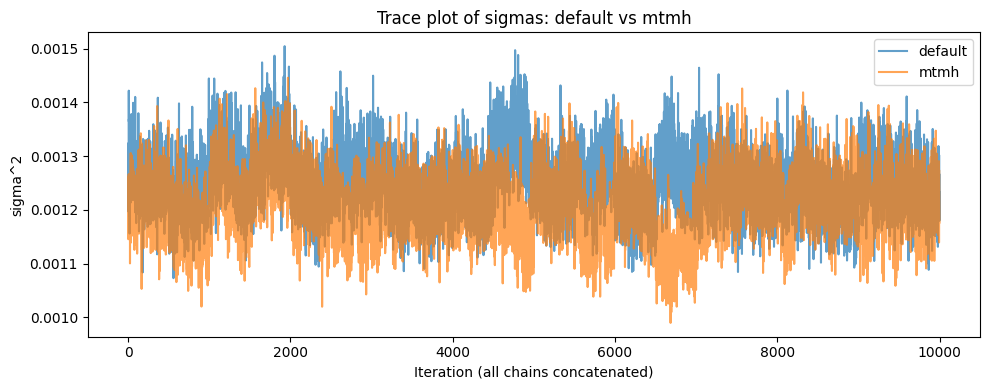

In [8]:
import matplotlib.pyplot as plt


# sigmas shape: (n_chains, ndpost)
sigmas_default = default_data["sigmas"].reshape(-1)
sigmas_mtmh = mtmh_data["sigmas"].reshape(-1)

# trace plot
plt.figure(figsize=(10, 4))
plt.plot(sigmas_default, label="default", alpha=0.7)
plt.plot(sigmas_mtmh, label="mtmh", alpha=0.7)
plt.xlabel("Iteration (all chains concatenated)")
plt.ylabel("sigma^2")
plt.title("Trace plot of sigmas: default vs mtmh")
plt.legend()
plt.tight_layout()
plt.show()

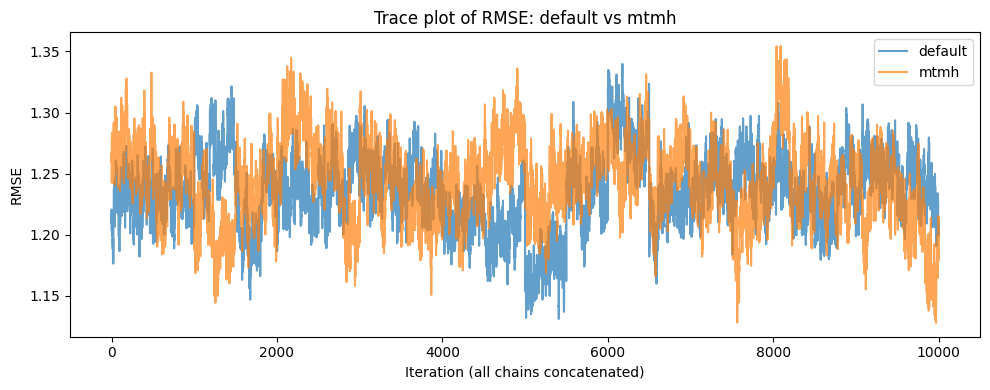

In [9]:
import matplotlib.pyplot as plt

# rmse shape: (n_chains, ndpost)
rmse_default = default_data["rmses"].reshape(-1)
rmse_mtmh = mtmh_data["rmses"].reshape(-1)

# trace plot
plt.figure(figsize=(10, 4))
plt.plot(rmse_default, label="default", alpha=0.7)
plt.plot(rmse_mtmh, label="mtmh", alpha=0.7)
plt.xlabel("Iteration (all chains concatenated)")
plt.ylabel("RMSE")
plt.title("Trace plot of RMSE: default vs mtmh")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
import numpy as np

preds_default = default_data["preds"]      # (n_chains, n_test, ndpost)
preds_mtmh    = mtmh_data["preds"]        # (n_chains, n_test, ndpost)

# Reconstruct the common train/test split (must match experiment.run_chain)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Recreate the subset of test points used for stored preds
n_test_points = 100
rng = np.random.default_rng(42)
if n_test_points is not None and n_test_points < X_test.shape[0]:
    idx = rng.choice(X_test.shape[0], n_test_points, replace=False)
else:
    idx = np.arange(X_test.shape[0])

y_test_sub = y_test[idx]  # shape (n_test_points,)

# preds_default / preds_mtmh shapes: (n_chains, n_test_points, ndpost)
# Average over all chains and ndpost for each test point
mean_preds_default = preds_default.mean(axis=(0, 2))  # shape (n_test_points,)
mean_preds_mtmh    = preds_mtmh.mean(axis=(0, 2))     # shape (n_test_points,)

# Overall RMSE across these test points
rmse_default_mean = root_mean_squared_error(y_test_sub, mean_preds_default)
rmse_mtmh_mean    = root_mean_squared_error(y_test_sub, mean_preds_mtmh)

print(f"RMSE (posterior mean, default): {rmse_default_mean:.4f}")
print(f"RMSE (posterior mean, mtmh):    {rmse_mtmh_mean:.4f}")

RMSE (posterior mean, default): 1.1312
RMSE (posterior mean, mtmh):    1.1421


In [11]:
from sklearn.model_selection import train_test_split
import numpy as np

# Load posterior predictive samples for each method
preds_default = default_data["preds"]   # shape: (n_chains, n_test_points, ndpost)
preds_mtmh    = mtmh_data["preds"]      # shape: (n_chains, n_test_points, ndpost)

# Reconstruct the common train/test split (must match experiment.run_chain)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Number of test points stored in preds
n_chains, n_test_points, ndpost = preds_default.shape

# Recreate the subset of test points used for stored preds (same RNG & seed)
rng = np.random.default_rng(42)
if n_test_points is not None and n_test_points < X_test.shape[0]:
    idx = rng.choice(X_test.shape[0], n_test_points, replace=False)
else:
    idx = np.arange(X_test.shape[0])

y_test_sub = y_test[idx]  # shape (n_test_points,)

def crps_from_samples(samples, y_true):
    """Compute CRPS for scalar outcomes from posterior samples.

    samples: array of shape (n_points, n_samples)
    y_true:  array of shape (n_points,)
    Returns: array of shape (n_points,) with CRPS for each point.
    """
    n_points, n_samples = samples.shape

    # First term: E|X - y|
    term1 = np.mean(np.abs(samples - y_true[:, None]), axis=1)

    # Second term: (1 / (2N^2)) * sum_{i,j} |x_i - x_j|
    # Computed efficiently using sorted samples:
    #   (1 / (2N^2)) * sum_{i,j} |x_i - x_j| = (1 / N^2) * sum_{k}(2k - N - 1) x_(k)
    samples_sorted = np.sort(samples, axis=1)
    k = np.arange(1, n_samples + 1)
    coeffs = (2 * k - n_samples - 1)[None, :]  # shape (1, n_samples)
    term2 = np.sum(coeffs * samples_sorted, axis=1) / (n_samples ** 2)

    return term1 - term2

# Reshape preds so that all chains × ndpost are treated as posterior samples
# For each test point: samples_default[i] has shape (n_chains * ndpost,)
n_chains_d, n_points_d, ndpost_d = preds_default.shape
samples_default = preds_default.transpose(1, 0, 2).reshape(n_points_d, n_chains_d * ndpost_d)

n_chains_m, n_points_m, ndpost_m = preds_mtmh.shape
samples_mtmh = preds_mtmh.transpose(1, 0, 2).reshape(n_points_m, n_chains_m * ndpost_m)

# CRPS per test point
crps_default = crps_from_samples(samples_default, y_test_sub)
crps_mtmh    = crps_from_samples(samples_mtmh, y_test_sub)

print(f"Mean CRPS (default): {crps_default.mean():.6f}")
print(f"Mean CRPS (mtmh):    {crps_mtmh.mean():.6f}")

Mean CRPS (default): 0.687567
Mean CRPS (mtmh):    0.700179


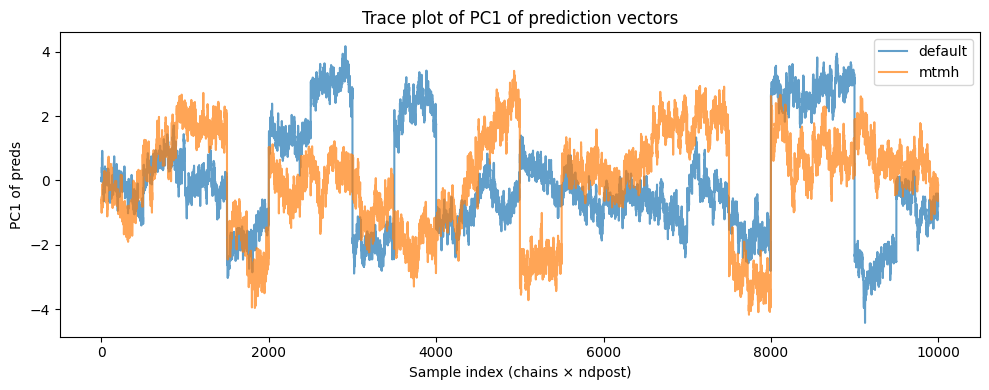

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

preds_default = default_data["preds"]      # (n_chains, n_test, ndpost)
preds_mtmh    = mtmh_data["preds"]        # (n_chains, n_test, ndpost)

# (n_chains, n_test, ndpost) -> (n_chains, ndpost, n_test) -> (n_chains * ndpost, n_test)
def reshape_for_pca(preds):
    n_chains, n_test, ndpost = preds.shape
    return preds.transpose(0, 2, 1).reshape(-1, n_test)

X_default = reshape_for_pca(preds_default)
X_mtmh    = reshape_for_pca(preds_mtmh)

# PCA
pca_default = PCA(n_components=1)
pc1_default = pca_default.fit_transform(X_default)[:, 0]

pca_mtmh = PCA(n_components=1)
pc1_mtmh = pca_mtmh.fit_transform(X_mtmh)[:, 0]

# PC1 trace plot
plt.figure(figsize=(10, 4))
plt.plot(pc1_default, label="default", alpha=0.7)
plt.plot(pc1_mtmh, label="mtmh", alpha=0.7)
plt.xlabel("Sample index (chains × ndpost)")
plt.ylabel("PC1 of preds")
plt.title("Trace plot of PC1 of prediction vectors")
plt.legend()
plt.tight_layout()
plt.show()

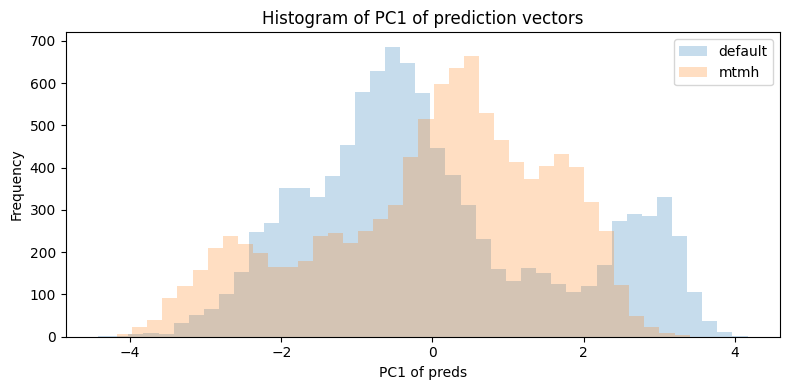

In [13]:
# histogram of PC1
plt.figure(figsize=(8, 4))
plt.hist(pc1_default, bins='auto', alpha=0.25, label="default")
plt.hist(pc1_mtmh, bins='auto', alpha=0.25, label="mtmh")
plt.xlabel("PC1 of preds") 
plt.ylabel("Frequency")
plt.title("Histogram of PC1 of prediction vectors")
plt.legend()
plt.tight_layout()
plt.show()

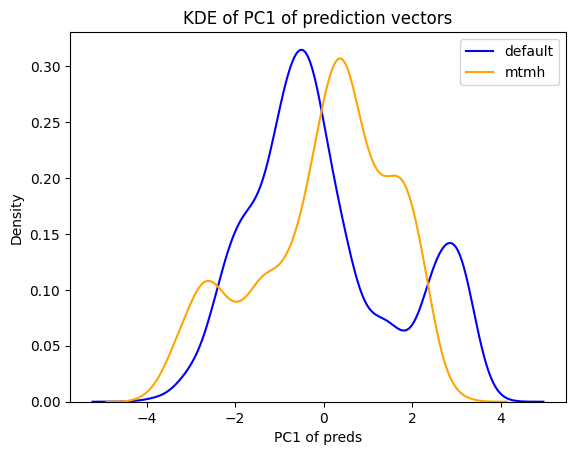

In [14]:
fig, ax = plt.subplots()
import seaborn as sns
sns.kdeplot(pc1_default, label="default", ax=ax, color='blue')
sns.kdeplot(pc1_mtmh, label="mtmh", ax=ax, color='orange')
ax.set_xlabel("PC1 of preds")
ax.set_ylabel("Density")
ax.set_title("KDE of PC1 of prediction vectors")
ax.legend()
plt.show()

# Comparison

In [15]:
notebook1 = "syn1_Friedman_1_10000"
notebook2 = "syn1_Friedman_100_100"
notebook3 = "syn1_Friedman_1000_10"
notebook4 = "syn1_Friedman_100_100_long"
notebook5 = "syn1_Friedman_20_500_long"

In [16]:
from sklearn.model_selection import train_test_split
import numpy as np

def friedman_noiseless(X_arr):
    """Noiseless Friedman (1991) regression function."""
    return (
        10.0 * np.sin(np.pi * X_arr[:, 0] * X_arr[:, 1])
        + 20.0 * (X_arr[:, 2] - 0.5) ** 2
        + 10.0 * X_arr[:, 3]
        + 5.0 * X_arr[:, 4]
    )

# Reconstruct the common train/test split (must match experiment.run_chain)
_, X_test, _, y_test = train_test_split(X, y, random_state=42)

# Use notebook1 as reference to recover the exact stored test subset size
ref_data = np.load(f"store/{notebook1}.npz", allow_pickle=True)
ref_preds = ref_data["default"].item()["preds"]
_, n_test_points, _ = ref_preds.shape

# Recreate the subset of test points used for stored preds (same RNG & seed)
rng = np.random.default_rng(42)
if n_test_points is not None and n_test_points < X_test.shape[0]:
    idx = rng.choice(X_test.shape[0], n_test_points, replace=False)
else:
    idx = np.arange(X_test.shape[0])

X_test_sub = X_test[idx]
f_true_sub = friedman_noiseless(X_test_sub)
y_test_sub = y_test[idx]

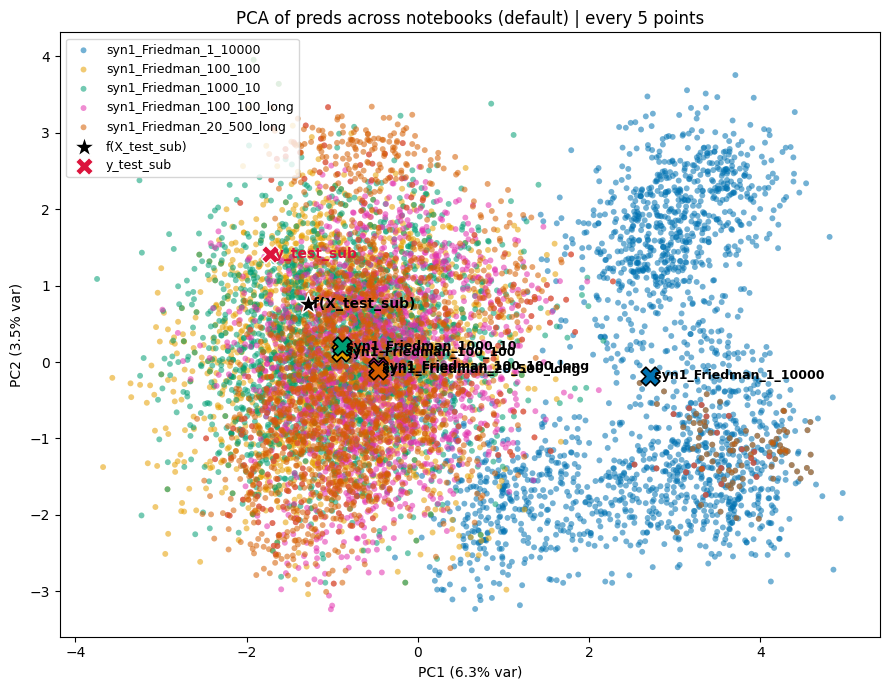

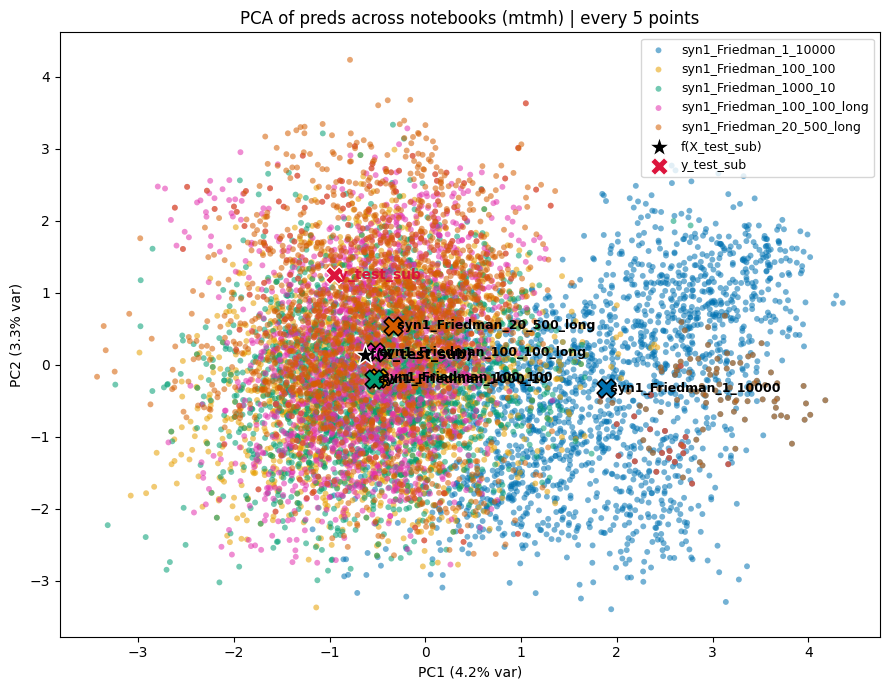

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def preds_to_matrix(npz_data, method_key):
    """Convert preds to shape (n_samples, n_test_points) for PCA."""
    preds = npz_data[method_key].item()["preds"]  # (n_chains, n_test, ndpost)
    n_chains, n_test, ndpost = preds.shape
    return preds.transpose(0, 2, 1).reshape(n_chains * ndpost, n_test)

def get_distinct_colors(n):
    """Return high-contrast colors for a small number of groups."""
    base_colors = ["#0072B2", "#E69F00", "#009E73", "#E22FAD", "#D55E00"]
    if n <= len(base_colors):
        return base_colors[:n]

    cmap = plt.get_cmap("tab10")
    return [cmap(i % 10) for i in range(n)]

def plot_notebooks_pca(
    notebook_names,
    method_key,
    plot_step=5,
    mark_centroid=True,
    true_ref=None,
    true_ref_label="f(X_test_sub)",
    observed_ref=None,
    observed_ref_label="y_test_sub",
):
    mats = []
    labels = []

    for name in notebook_names:
        data = np.load(f"store/{name}.npz", allow_pickle=True)
        mats.append(preds_to_matrix(data, method_key))
        labels.append(name)

    X_all = np.vstack(mats)
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(X_all)

    plt.figure(figsize=(9, 7))
    colors = get_distinct_colors(len(labels))

    start = 0
    for i, (mat, label) in enumerate(zip(mats, labels)):
        n = mat.shape[0]
        segment = pcs[start:start + n]
        idx = np.arange(0, n, plot_step)

        plt.scatter(
            segment[idx, 0],
            segment[idx, 1],
            s=18,
            alpha=0.55,
            label=label,
            c=[colors[i]],
            edgecolors="none"
        )

        if mark_centroid:
            centroid = segment.mean(axis=0)
            plt.scatter(
                centroid[0],
                centroid[1],
                s=180,
                c=[colors[i]],
                marker="X",
                edgecolors="black",
                linewidths=1.2,
                zorder=5
            )
            plt.text(
                centroid[0],
                centroid[1],
                f" {label}",
                fontsize=9,
                weight="bold",
                va="center",
                ha="left",
                zorder=6
            )

        start += n

    # Overlay noiseless Friedman target f(X_test_sub), like the original notebook.
    if true_ref is not None:
        true_ref = np.asarray(true_ref).reshape(1, -1)
        if true_ref.shape[1] != X_all.shape[1]:
            raise ValueError(
                f"true_ref has length {true_ref.shape[1]}, but PCA expects {X_all.shape[1]} features."
            )
        true_proj = pca.transform(true_ref)[0]
        plt.scatter(
            true_proj[0],
            true_proj[1],
            s=260,
            c="black",
            marker="*",
            edgecolors="white",
            linewidths=1.1,
            zorder=8,
            label=true_ref_label
        )
        plt.text(
            true_proj[0],
            true_proj[1],
            f" {true_ref_label}",
            fontsize=10,
            color="black",
            weight="bold",
            va="center",
            ha="left",
            zorder=9
        )

    # Optional: also overlay noisy observation y_test_sub.
    if observed_ref is not None:
        observed_ref = np.asarray(observed_ref).reshape(1, -1)
        if observed_ref.shape[1] != X_all.shape[1]:
            raise ValueError(
                f"observed_ref has length {observed_ref.shape[1]}, but PCA expects {X_all.shape[1]} features."
            )
        observed_proj = pca.transform(observed_ref)[0]
        plt.scatter(
            observed_proj[0],
            observed_proj[1],
            s=170,
            c="crimson",
            marker="X",
            edgecolors="white",
            linewidths=1.0,
            zorder=8,
            label=observed_ref_label
        )
        plt.text(
            observed_proj[0],
            observed_proj[1],
            f" {observed_ref_label}",
            fontsize=10,
            color="crimson",
            weight="bold",
            va="center",
            ha="left",
            zorder=9
        )

    evr = pca.explained_variance_ratio_
    plt.xlabel(f"PC1 ({evr[0] * 100:.1f}% var)")
    plt.ylabel(f"PC2 ({evr[1] * 100:.1f}% var)")
    plt.title(f"PCA of preds across notebooks ({method_key}) | every {plot_step} points")
    plt.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.show()

# Put any number of notebooks here.
notebooks = [notebook1, notebook2, notebook3, notebook4, notebook5]

# default and mtmh are plotted separately.
# Keep f(X_test_sub) marker (true_ref) like the original notebook.
plot_notebooks_pca(
    notebooks,
    method_key="default",
    plot_step=5,
    mark_centroid=True,
    true_ref=f_true_sub,
    true_ref_label="f(X_test_sub)",
    observed_ref=y_test_sub,
    observed_ref_label="y_test_sub",
)
plot_notebooks_pca(
    notebooks,
    method_key="mtmh",
    plot_step=5,
    mark_centroid=True,
    true_ref=f_true_sub,
    true_ref_label="f(X_test_sub)",
    observed_ref=y_test_sub,
    observed_ref_label="y_test_sub",
)